# Example training and auditing a simple PyTorch model with SACRO-ML

## Overview

1. The researcher creates `dataset.py`, `model.py`, and `train.py` files containing standard modular PyTorch code for preprocessing data and training a model.
2. The researcher creates a script to execute the aforementioned modules, training, and then saving the final model along with the code using a helper wrapper class from the SACRO-ML library called `Target`.
3. The researcher or an auditor then runs a script for loading the saved model and code, defines the audits (attacks) to run and executes them, generating a report.

## Researcher: dataset.py

Dataset handling functions can be supplied in a module named `dataset.py`.

* The `dataset.py` must contain a class for creating/loading the data.
* The dataset class must implement the abstract `sacroml.attacks.data.PyTorchDataHandler`.
* This module can subsequently be passed to the `sacroml.attacks.target.Target` convienence class to wrap the model and data for running privacy audits.
  - The file path to the dataset module must later be specified in the `Target` class with `dataset_module_path`.
  - The `Target` parameter `dataset_name` must match the name of the dataset class.
  - If supplying a `dataset_module_path` the indices must be passed as `indices_train` and `indices_test`.
  - If you do not use a `dataset.py`, you can pass numpy arrays directly to `Target` as `X_train`, etc., and the data will be copied.

In [1]:
%%writefile dataset.py

"""Example dataset handler with Synthetic data."""

from collections.abc import Sequence

import torch
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset

from sacroml.attacks.data import PyTorchDataHandler

random_state = 2


class Synthetic(PyTorchDataHandler):
    """Synthetic dataset handler."""

    def __init__(self) -> None:
        """Create synthetic data."""
        self.X, self.y = make_classification(
            n_samples=50,
            n_features=4,
            n_informative=2,
            n_redundant=0,
            n_repeated=0,
            n_classes=4,
            n_clusters_per_class=1,
            random_state=random_state,
        )

        # Store raw unprocessed data
        X_tensor = torch.FloatTensor(self.X)
        y_tensor = torch.LongTensor(self.y)
        self.raw_dataset = TensorDataset(X_tensor, y_tensor)

        # Preprocess
        self.feature_encoder = StandardScaler()
        X_transformed = self.feature_encoder.fit_transform(self.X)

        # Store processed data
        X_tensor = torch.FloatTensor(X_transformed)
        y_tensor = torch.LongTensor(self.y)
        self.dataset = TensorDataset(X_tensor, y_tensor)

    def __len__(self) -> int:
        """Return the length of the dataset."""
        return len(self.dataset)

    def get_raw_dataset(self) -> Dataset | None:
        """Return a raw unprocessed dataset."""
        return self.raw_dataset

    def get_dataset(self) -> Dataset:
        """Return a preprocessed dataset."""
        return self.dataset

    def get_dataloader(
        self,
        dataset: Dataset,
        indices: Sequence[int],
        batch_size: int = 32,
        shuffle: bool = False,
    ) -> DataLoader:
        """Return a data loader with a requested subset of samples."""
        subset = Subset(dataset, indices)
        return DataLoader(subset, batch_size=batch_size, shuffle=shuffle)

    def get_train_test_indices(self) -> tuple[Sequence[int], Sequence[int]]:
        """Return train and test set indices."""
        indices = range(len(self))
        train, test = train_test_split(
            indices, test_size=0.2, stratify=self.y, random_state=random_state
        )
        return train, test

Writing dataset.py


## Researcher: model.py

The PyTorch model class can be supplied in a module named `model.py`.

* The `model.py` must contain a PyTorch model class with a constructor.
* This module can subsequently be passed to the `sacroml.attacks.target.Target` wrapper class.
  - All parameters used by the constructor must be specified under `model_params`.
  - The file path to the model module must be specified under `model_module_path`.

In [2]:
%%writefile model.py

"""An example Pytorch classifier."""

import torch


class OverfitNet(torch.nn.Module):
    """An example Pytorch classification model."""

    def __init__(self, x_dim: int, y_dim: int, n_units: int) -> None:
        """Construct a simple Pytorch model."""
        super().__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(x_dim, n_units),
            torch.nn.ReLU(),
            torch.nn.Linear(n_units, y_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward propagate input."""
        return self.layers(x)

Writing model.py


## Researcher: train.py

Model training functions can be supplied in a module named `train.py`.

* The `train.py` must contain a `train()` function.
* The `train()` function must have parameters:
  - `model: torch.nn.Module` PyTorch model to train.
  - `dataloader: torch.utils.data.DataLoader` training set DataLoader.
* The `train()` function may contain optional extra parameters.
* The file path to this training module can later be supplied to the `sacroml.attacks.target.Target` wrapper with `train_module_path`.
* All training parameters must be passed to `Target` with the argument `train_params`.

In [3]:
%%writefile train.py

"""An example PyTorch training module."""

import torch
from torch import nn, optim
from torch.utils.data import DataLoader


def train(
    model: nn.Module,
    dataloader: DataLoader,
    epochs: int,
    learning_rate: float,
    momentum: float,
) -> None:
    """Train model."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)

    model.train()
    for _ in range(epochs):
        for inputs, labels in dataloader:
            X = inputs.to(device, non_blocking=True)
            y = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()


def get_accuracy(model: nn.Module, dataloader: DataLoader) -> float:
    """Return model accuracy as a percentage."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            X, y = inputs.to(device), labels.to(device)
            logits = model(X)
            _, predicted = torch.max(logits, 1)

            correct += (predicted == y).sum().item()
            total += y.size(0)

    return 100 * correct / total

Writing train.py


## Researcher: Execute training and save model and data

This creates a "target" folder with the saved model and source code for subsequent auditing.

In [4]:
"""Train a classifier on synthetic data using sacroml Target and Dataset classes."""

import logging

import torch
import train
from dataset import Synthetic
from model import OverfitNet

from sacroml.attacks.target import Target

target_dir = "target_pytorch"
random_state = 2

torch.manual_seed(random_state)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_state)
    logging.info(torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    logging.info("Found no NVIDIA driver on your system")

#############################################################################
# Dataset loading and model training
#############################################################################

logging.info("Loading dataset")

# Access dataset
data_handler = Synthetic()

# Get the (preprocessed) dataset
dataset = data_handler.get_dataset()

# Create data splits
indices_train, indices_test = data_handler.get_train_test_indices()

# Made explicit so the same value can be recorded on the Target below.
batch_size = 32
train_loader = data_handler.get_dataloader(
    dataset, indices_train, batch_size=batch_size, shuffle=True
)
test_loader = data_handler.get_dataloader(
    dataset, indices_test, batch_size=batch_size, shuffle=False
)

logging.info("Defining the model")

model_params = {
    "x_dim": 4,
    "y_dim": 4,
    "n_units": 1000,
}
train_params = {
    "epochs": 1000,
    "learning_rate": 0.001,
    "momentum": 0.9,
}
model = OverfitNet(**model_params)

logging.info("Training the model")
train.train(model, train_loader, **train_params)

logging.info("Evaluating the model")
train_acc = train.get_accuracy(model, train_loader)
test_acc = train.get_accuracy(model, test_loader)
print(f"Accuracy on train set: {train_acc:.2f}%")
print(f"Accuracy on test set: {test_acc:.2f}%")

#############################################################################
# Below shows the use of the Target class to help generate the target_dir/
# If you have already saved your model, you can use the CLI target generator.
#############################################################################

logging.info("Wrapping the model and data in a Target object")
target = Target(
    model=model,
    model_module_path="model.py",
    model_params=model_params,  # Must match all required in model constructor
    train_module_path="train.py",
    train_params=train_params,  # Must match all required in the train function
    batch_size=batch_size,  # Should match the training batch size
    dataset_module_path="dataset.py",
    dataset_name="Synthetic",  # Must match the class name in dataset module
    indices_train=indices_train,
    indices_test=indices_test,
)

logging.info("Writing Target object to directory: '%s'", target_dir)
target.save(target_dir)

INFO:root:NVIDIA GeForce RTX 4070 Laptop GPU
INFO:root:Loading dataset
INFO:root:Defining the model
INFO:root:Training the model
INFO:root:Evaluating the model
INFO:root:Wrapping the model and data in a Target object
INFO:root:Writing Target object to directory: 'target_pytorch'


Accuracy on train set: 100.00%
Accuracy on test set: 70.00%


## Researcher/Auditor: Define and execute the audit (attacks)

In this example we run: 
* `WorstCaseAttack` which trains a binary classifier to predict membership using the model confidence scores with the hypothesis that the output distributions differ for training and test records.
* `LIRAAttack` which trains reference models with the same parameters and architecture both with and without each record and estimates the loss distributions associated with membership and non-membership. Membership is then inferred via a likelihood-ratio test.
* `StructuralAttack` which computes various vulnerability metrics, including generalisation gap.

For each attack/audit the method is the same:
1. Create or load a `Target` object which includes the model and data to be audited.
2. Instantiate the desired attack/audit object.
3. Run the attack object's `attack()` method with the `Target` object passed. 

The results of the audit are saved in the "output" folder as machine-readable JSON and human-readable PDF. The results can also be interogated programmatically.

### Loading Target

In [5]:
"""Example of how to run attacks on a model saved with the Target wrapper."""

import logging

import matplotlib.pyplot as plt
import numpy as np

from sacroml.attacks.likelihood_attack import LIRAAttack
from sacroml.attacks.structural_attack import StructuralAttack
from sacroml.attacks.target import Target
from sacroml.attacks.worst_case_attack import WorstCaseAttack

output_dir = "output_pytorch"
target_dir = "target_pytorch"


logging.info("Loading Target object from '%s'", target_dir)

target = Target()
target.load(target_dir)

INFO:root:Loading Target object from 'target_pytorch'
INFO:sacroml.attacks.target:Loaded: PytorchModel : OverfitNet
INFO:sacroml.attacks.target:indices_train length: 40
INFO:sacroml.attacks.target:indices_test length: 10
INFO:sacroml.attacks.target:Loaded: X_train shape: (40, 4)
INFO:sacroml.attacks.target:Loaded: y_train shape: (40,)
INFO:sacroml.attacks.target:Loaded: X_test shape: (10, 4)
INFO:sacroml.attacks.target:Loaded: y_test shape: (10,)
INFO:sacroml.attacks.target:Loaded: X_train_orig shape: (40, 4)
INFO:sacroml.attacks.target:Loaded: y_train_orig shape: (40,)
INFO:sacroml.attacks.target:Loaded: X_test_orig shape: (10, 4)
INFO:sacroml.attacks.target:Loaded: y_test_orig shape: (10,)


### Binary attack classifier

In [6]:
attack = WorstCaseAttack(n_reps=10, output_dir=output_dir)
result = attack.attack(target)

INFO:sacroml.attacks.worst_case_attack:Running main attack repetitions
INFO:sacroml.attacks.worst_case_attack:Sorting probabilities to leave highest value in first column
INFO:sacroml.attacks.worst_case_attack:Creating MIA data
INFO:sacroml.attacks.worst_case_attack:Rep 1 of 10
INFO:sacroml.attacks.worst_case_attack:Rep 2 of 10
INFO:sacroml.attacks.worst_case_attack:Rep 3 of 10
INFO:sacroml.attacks.worst_case_attack:Rep 4 of 10
INFO:sacroml.attacks.worst_case_attack:Rep 5 of 10
INFO:sacroml.attacks.worst_case_attack:Rep 6 of 10
INFO:sacroml.attacks.worst_case_attack:Rep 7 of 10
INFO:sacroml.attacks.worst_case_attack:Rep 8 of 10
INFO:sacroml.attacks.worst_case_attack:Rep 9 of 10
INFO:sacroml.attacks.worst_case_attack:Rep 10 of 10
INFO:sacroml.attacks.worst_case_attack:Finished simulating attacks
INFO:sacroml.attacks.worst_case_attack:Running dummy attack reps
INFO:sacroml.attacks.worst_case_attack:Sorting probabilities to leave highest value in first column
INFO:sacroml.attacks.worst_ca

In [7]:
res = result["attack_experiment_logger"]["attack_instance_logger"]["instance_0"]

print(f"AUC            = {res['AUC']:.2f}")
print(f"TPR@0.1% FPR   = {res['TPR@0.1%']}")
print(f"TPR@0.001% FPR = {res['TPR@0.001%']}")

AUC            = 0.38
TPR@0.1% FPR   = 0.25
TPR@0.001% FPR = 0.25


### Likelihood ratio attack

In [8]:
attack = LIRAAttack(n_shadow_models=64, report_individual=True, output_dir=output_dir)
result = attack.attack(target)

INFO:sacroml.attacks.likelihood_attack:Running offline LiRA, fix_variance=False
INFO:sacroml.attacks.utils:Training shadow models
INFO:sacroml.attacks.utils:Found 64 models previously trained
INFO:sacroml.attacks.likelihood_attack:Getting signals from 64 shadow models
INFO:sacroml.attacks.likelihood_attack:Computing scores
INFO:sacroml.attacks.likelihood_attack:Finished scenario
INFO:sacroml.attacks.attack:Generating report
INFO:sacroml.attacks.attack:Writing report: output_pytorch/report.json output_pytorch/report.pdf


In [9]:
res = result["attack_experiment_logger"]["attack_instance_logger"]["instance_0"]

print(f"AUC            = {res['AUC']:.2f}")
print(f"TPR@0.1% FPR   = {res['TPR@0.1%']}")
print(f"TPR@0.001% FPR = {res['TPR@0.001%']}")
print(f"\nFraction of (out) losses normally distributed = {res['n_normal']}")

AUC            = 0.77
TPR@0.1% FPR   = 0.425
TPR@0.001% FPR = 0.425

Fraction of (out) losses normally distributed = 0.42


In [10]:
def roc_plot_single(metrics: dict) -> None:
    """Plot ROC for a single run."""
    plt.figure()
    plt.plot([0, 1], [0, 1], "k--")
    plt.plot(metrics["fpr"], metrics["tpr"], "r", linewidth=2)
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    plt.ylabel("True Positive Rate")
    plt.xlabel("False Positive Rate")


def plot_lira_individuals(metrics: dict) -> None:
    """Create a plot of the individual record LiRA scores."""
    scores = np.array(metrics["individual"]["member_prob"])
    member = np.array(metrics["individual"]["member"])

    _, axes = plt.subplots(1, 2, figsize=(12.4, 4.8), sharey=True)
    # members
    mask = member == 1
    y_train = scores[mask]
    x_train = np.arange(y_train.shape[0])

    sorted_indicies = np.argsort(y_train)
    y_sorted = y_train[sorted_indicies]

    axes[0].scatter(x_train, y_sorted, color="b", s=2)
    axes[0].set_title("Member Records")
    axes[0].set_xlabel("Record (sorted)")
    axes[0].set_ylabel("LiRA Probability")

    # nonmembers
    y_test = scores[~mask]
    x_test = np.arange(y_test.shape[0])

    sorted_indicies = np.argsort(y_test)
    y_sorted = y_test[sorted_indicies]

    axes[1].scatter(x_test, y_sorted, color="r", s=2)
    axes[1].set_title("Nonmember Records")
    axes[1].set_xlabel("Record (sorted)")

#### LiRA ROC curve

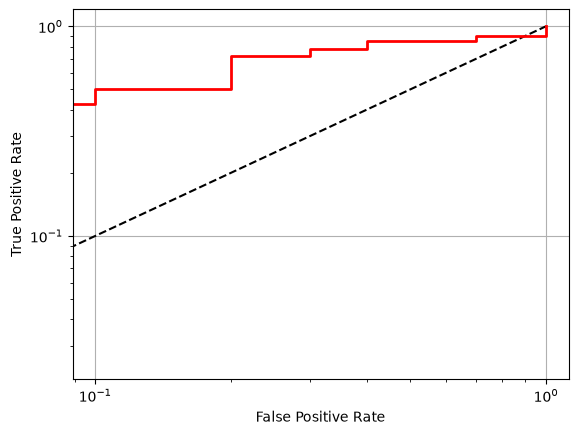

In [11]:
roc_plot_single(res)

#### LiRA record-level vulnerability scores

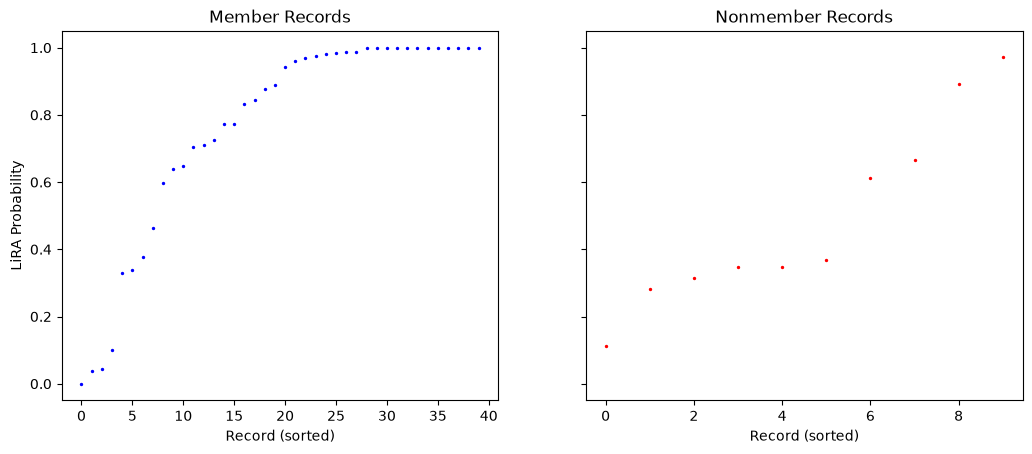

In [12]:
plot_lira_individuals(res)

#### LiRA 10 most vulnerable records

In [13]:
def print_topk_individuals(metrics: dict, k: int = 10) -> None:
    """Display the top-k most vulnerable records."""
    scores = np.array(metrics["individual"]["member_prob"])
    member = np.array(metrics["individual"]["member"])

    out_p_norm = np.array(metrics["individual"]["out_p_norm"])

    mask = member == 1
    y_train = scores[mask]

    sorted_indicies = np.argsort(y_train)

    print(f"LiRA {k} most vulnerable records:")
    top_indices = sorted_indicies[-k:][::-1]
    for i in top_indices:
        print(f"index: {i}, score: {y_train[i]:.2f}  (p_norm={out_p_norm[i]:.2f})")

In [14]:
print_topk_individuals(res, k=10)

LiRA 10 most vulnerable records:
index: 24, score: 1.00  (p_norm=0.63)
index: 11, score: 1.00  (p_norm=0.95)
index: 26, score: 1.00  (p_norm=0.18)
index: 18, score: 1.00  (p_norm=0.31)
index: 32, score: 1.00  (p_norm=0.00)
index: 37, score: 1.00  (p_norm=0.92)
index: 30, score: 1.00  (p_norm=0.68)
index: 23, score: 1.00  (p_norm=0.35)
index: 35, score: 1.00  (p_norm=0.07)
index: 20, score: 1.00  (p_norm=0.04)


### Structural Metrics

In [15]:
attack = StructuralAttack(output_dir=output_dir)
result = attack.attack(target)

INFO:acro:version: 1.0.1
INFO:acro:config: {'safe_threshold': 10, 'safe_dof_threshold': 10, 'safe_nk_n': 2, 'safe_nk_k': 0.9, 'safe_pratio_p': 0.1, 'check_missing_values': False, 'survival_safe_threshold': 10, 'zeros_are_disclosive': True, 'safe_round_base': 5, 'federated': False, 'blocked_extensions': ['.svg', '.gph'], 'suppress': False}
INFO:acro:mitigation: none (round_base=5)
INFO:acro:federated: False
INFO:sacroml.attacks.structural_attack:Thresholds for count 10 and DoF 10
INFO:sacroml.attacks.structural_attack:Class of module is <class 'target_pytorch.model.OverfitNet'> 
INFO:sacroml.attacks.structural_attack:Samples=40, Parameters=9004, DoF=-8964
INFO:sacroml.attacks.structural_attack:Unnecessary risk not define for models of type <class 'target_pytorch.model.OverfitNet'>
INFO:sacroml.attacks.structural_attack:Smallest equivalence class size (k-anonymity) is 1
INFO:sacroml.attacks.attack:Generating report
INFO:sacroml.attacks.attack:Writing report: output_pytorch/report.json ou

In [16]:
res = result["attack_experiment_logger"]["attack_instance_logger"]["instance_0"]

print(f"Generalisation Gap    = {res['generalisation_gap']:.2f}")
print(f"DoF Risk              = {res['dof_risk']}")
print(f"k Anonymity Risk      = {res['k_anonymity_risk']}")
print(f"Class Disclosure Risk = {res['class_disclosure_risk']}")
print(f"Small Group Risk      = {res['smallgroup_risk']}")

Generalisation Gap    = 0.30
DoF Risk              = True
k Anonymity Risk      = True
Class Disclosure Risk = True
Small Group Risk      = True


### Report PDF

In [17]:
import os

from IPython.display import display
from pdf2image import convert_from_path


def show_pdf() -> None:
    """Display PDF report generated."""
    report_path: str = os.path.join(output_dir, "report.pdf")

    pages = convert_from_path(report_path, dpi=150)
    for page in pages:
        display(page)

In [ ]:
show_pdf()

## TODO: federated learning and flower AI

---

## Demo clean up

Remove all generated files (except shadow models) so this notebook can be rerun if necessary.

In [19]:
import shutil


def clean_up() -> None:
    """Remove generated files."""
    # Researcher PyTorch modules
    for file_path in ("dataset.py", "model.py", "train.py"):
        if os.path.exists(file_path):
            os.remove(file_path)

    # Saved target model
    shutil.rmtree(target_dir, ignore_errors=True)

    # Generated outputs - except shadow models
    if os.path.exists(output_dir):
        for item in os.listdir(output_dir):
            item_path = os.path.join(output_dir, item)
            if os.path.isfile(item_path):
                os.remove(item_path)


clean_up()